# Data Pre- Processing & EDA

## Imports 

In [1]:
import requests, time, csv, pathlib
from datetime import datetime, timezone
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## 1 Pre‑processing & Exploratory Data Analysis

In [2]:
df = pd.read_csv("data/reviews.csv")
df['dt']    = pd.to_datetime(df['unix_time'], unit='s', utc=True)
df['len']   = df['text'].str.len()
df = df[(df['len'] >= 8)].drop_duplicates('id') # מוריד חוות דעת ריקות ממלל
df = df.drop_duplicates('text')
print("Clean rows:", len(df))

print(df.isnull().sum()) # בדיקה האם נשארו ערכי נאל.
print(df.describe())


Clean rows: 22651
app_id            0
id                0
unix_time         0
thumbs_up         0
minutes_played    0
useful_score      0
text              0
dt                0
len               0
dtype: int64
              app_id            id     unix_time     thumbs_up  \
count   22651.000000  2.265100e+04  2.265100e+04  22651.000000   
mean   246441.026886  1.519885e+08  1.687037e+09      0.705399   
std    285494.371126  5.740725e+07  9.175500e+07      0.455873   
min       570.000000  2.957286e+06  1.349013e+09      0.000000   
25%       730.000000  1.447529e+08  1.692657e+09      0.000000   
50%       730.000000  1.768525e+08  1.728684e+09      1.000000   
75%    578080.000000  1.916795e+08  1.743458e+09      1.000000   
max    578080.000000  1.934786e+08  1.745501e+09      1.000000   

       minutes_played  useful_score           len  
count    2.265100e+04  22651.000000  22651.000000  
mean     6.950197e+04      0.503910    115.048121  
std      1.191634e+05      0.023024   

#### **So What we know about our data so far?** 
* "thumbs_up" says if the user that left the review liked (1) or disliked (0) the game. <br> 
* As you can see, "thumbs_up" mean is 0.73 - which means that **73% of the users tend to like the games**. <br> 
* Most of "useful_score" scores are exactly 0.5 - which says that mos of them are neutral (no up/down votes).

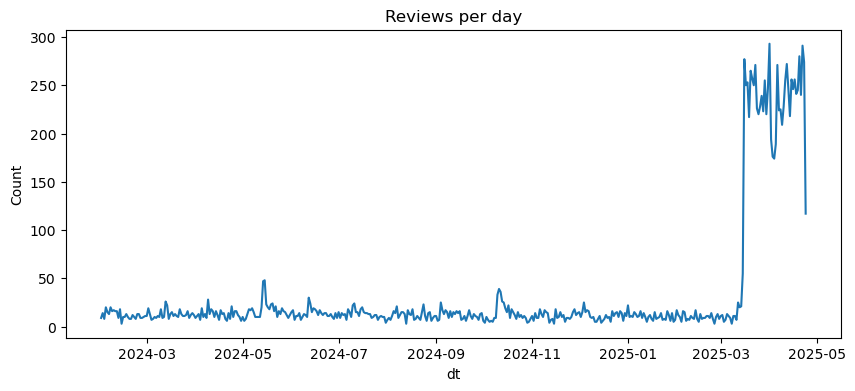

In [3]:
df_recent = df[df["dt"] >= "2024-02-01"] #(3 months back)
df_recent.groupby(df_recent["dt"].dt.date)["id"].count().plot(figsize=(10,4), title="Reviews per day")
plt.ylabel("Count")
plt.show()
# Simple EDA plot

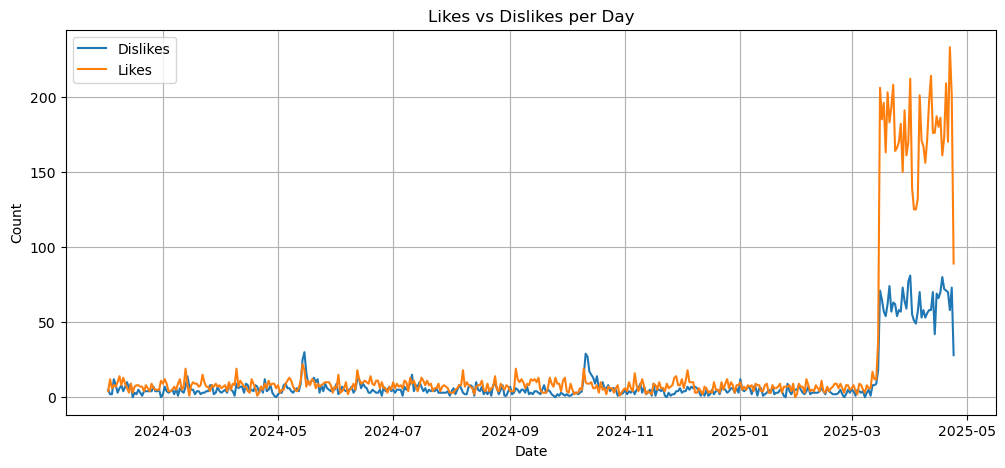

In [4]:
# Step 1: Grouping by day and label
df_recent = df[df["dt"] >= "2024-02-01"] # taking only recent relevant dates (3 months back)
daily_counts = df.groupby([df_recent["dt"].dt.date, "thumbs_up"]).size().unstack(fill_value=0)

# Step 2: Rename columns for clarity
daily_counts.columns = ["Dislikes", "Likes"]  # because 0 = dislike, 1 = like

# Step 3: Plot
daily_counts.plot(kind="line", figsize=(12, 5), title="Likes vs Dislikes per Day")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True)
plt.show()


As you can see, most of the reviews are from the recent month.
It is probably due to steam's **truncated historical data** — the kind you get when Steam limits review scraping to recent posts by default..
Let's zoom in to data between the dates of september to november (2024):

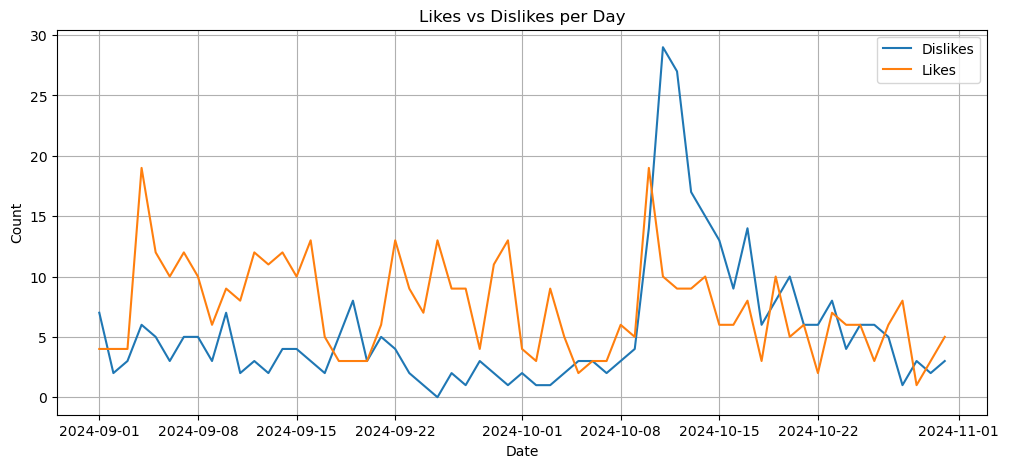

In [5]:
# Step 1: Grouping by day and label
df_recent = df[(df["dt"] >= "2024-09-01") & (df["dt"] <= "2024-11-01")] # taking only recent relevant dates (3 months back)
daily_counts = df.groupby([df_recent["dt"].dt.date, "thumbs_up"]).size().unstack(fill_value=0)

# Step 3: Rename columns for clarity
daily_counts.columns = ["Dislikes", "Likes"]  # because 0 = dislike, 1 = like

# Step 4: Plot
daily_counts.plot(kind="line", figsize=(12, 5), title="Likes vs Dislikes per Day")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True)
plt.show()


So after we "dived-in" into the area of this timezone: <br>We can see that between 10.08 to 10.15 there is a "strange" change - there was more dislikes than likes.
Trying to explain this behavior, after searching the web we **found out** that: <br> ​"The surge in negative reviews between October 8 and October 15, 2025, for Dota 2, Counter-Strike 2 (CS2), and PUBG appears to be linked to a **combination of in-game updates** and community reactions during that period."

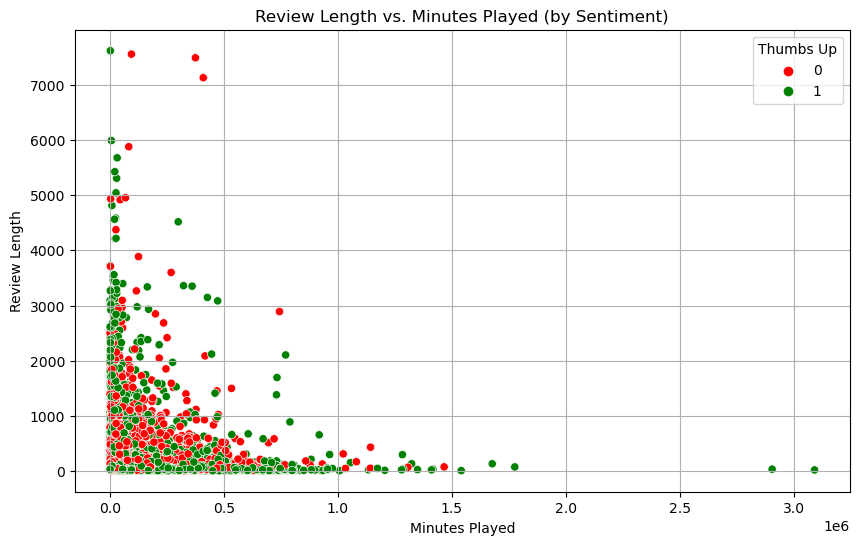

In [6]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="minutes_played", y="len", hue="thumbs_up", data=df, palette=["red", "green"])
plt.title("Review Length vs. Minutes Played (by Sentiment)")
plt.xlabel("Minutes Played")
plt.ylabel("Review Length")
plt.grid(True)
plt.legend(title="Thumbs Up")
plt.show()

- Players with very little time can write very long reviews (often complaints or strong reactions).
- High-hour players tend to write shorter reviews, possibly due to familiarity or fatigue.
- Long playtime does not always correlate with positive sentiment — many thumbs-down reviews exist even at 5000+ hours.
- Most reviews are short (~0–500 chars), regardless of hours played.
- The distribution suggests that vocal reviews come from all types of users — not just veterans or fans.

🔻 The more someone plays, the shorter their review tends to be <br>
There’s a visible downward density slope:

As minutes_played increases, len mostly shrinks toward 0–500 chars.

Veteran players might leave short but confident reviews (“GG” (good game in short), “trash”, “CS2 = broken”).